# Analiza nepremičnin v Ljubljani

## Uvod
Temo, nepremičninski trg Ljubljane, sem izbrala, ker gre za eno najbolj aktualnih problemov sodobne družbe. Visoke cene nepremičnin v Ljubljani so resna družbena težava, ki številne ljudi sili v odseljevanje v manjša mesta ter predmestja. V nalogi me je zanimalo, kako se to odraža s cenami, zato sem v ospredje postavila analizo treh ključnih dejavnikov: cena, velikost in leto izgradnje nepremičnin. Podatke o nepremičninah sem pridobila na spletni strani https://www.nepremicnine.net/oglasi-prodaja/ljubljana-mesto/stanovanje/. S pomočjo obdelave podatkov želim analizirati cenovne razlike in prikazati realno sliko trga. 

## Priprava podatkov in osnovna statistika

Za izvedbo analize sem v `uredi.py` poskrbela za branje in čiščenje surovih podatkov iz datoteke CSV. V spodnjem koraku sem dodala osnovne tržne pokazatelje, kot so število oglasov, povprečna cena, površina in cenovna ekstrema.

In [93]:
import uredi
import matplotlib.pyplot as plt
import statistics
import numpy as np
from pathlib import Path


OSNOVNA_MAPA = Path.cwd()
path = OSNOVNA_MAPA / "SUROVI_PODATKI" / "nepremicnine_ljubljana.csv"
cene, tipi, velikosti, leta = uredi.nalozi_podatke(path)


In [71]:
skupaj_oglasov = len(cene)

if skupaj_oglasov > 0:
    povprecna_cena = sum(cene) / skupaj_oglasov
    povprecna_velikost = sum(velikosti) / skupaj_oglasov

    skupna_cena = sum(cene)
    skupna_povrsina = sum(velikosti)

    print("ANALIZA NEPREMIČNIN V LJUBLJANI:")
    print(f"Število uspešno obdelanih oglasov: {skupaj_oglasov}")
    print(f"Povprečna cena nepremičnine: {povprecna_cena:,.2f} €")
    print(f"Povprečna velikost nepremičnine: {povprecna_velikost:.2f} m2")
    print(f"Najdražja nepremičnina: {max(cene):,.2f} €")
    print(f"Najcenejša nepremičnina: {min(cene):,.2f} €")
else:
    print("V datoteki ni bilo ustreznih podatkov za izračun.")

ANALIZA NEPREMIČNIN V LJUBLJANI:
Število uspešno obdelanih oglasov: 671
Povprečna cena nepremičnine: 575,268.75 €
Povprečna velikost nepremičnine: 106.61 m2
Najdražja nepremičnina: 3,200,000.00 €
Najcenejša nepremičnina: 9,500.00 €


Iz izračunov je razvidno, da vzorec obsega 671 veljavnih oglasov. Povprečna cena nepremičnine v Ljubljani znaša 575,268.75 €, pri čemer je povprečna cena na kvadratni meter 5,396.11 €, kar že prikazuje zelo visoke cene na ljubljanskem nepremičninskem trgu. 

## Analiza in vizualizacija podatkov
V tem poglavju podrobneje analiziram ugotovitve z uporabo grafičnih elementov in statističnih pokazateljev. Vizualizacije pomagajo odkriti skrite trende, razmerja med lastnostmi nepremičnin ter vpliv starosti objektov na končno ceno.

### Velikost nepremičnine
Cilj je bil najprej izračunati najvišjo, najnižjo ter povprečno ceno nepremičnin na m2 ter mediano, ker ta ni občutljiva na ekstremne vrednosti (zelo drage ali zelo poceni nepremičnine), ki zelo vplivajo na povprečje. Tako poda bolj realno sliko o dejanskim cenam, s katerimi se srečuje povprečni kupec. 

In [72]:
cene_na_m2 = [c / v for c, v in zip(cene, velikosti) if v > 0]
povprecna_cena_na_m2 = skupna_cena / skupna_povrsina if skupna_povrsina > 0 else 0
if cene_na_m2:
    povprecna_m2 = sum(cene_na_m2) / len(cene_na_m2)
    print(f"Povprečna cena na m2: {povprecna_m2:,.2f} €/m2")
    print(f"Najvišja cena na m2: {max(cene_na_m2):,.2f} €/m2")
    print(f"Najnižja cena na m2: {min(cene_na_m2):,.2f} €/m2")

Povprečna cena na m2: 5,662.69 €/m2
Najvišja cena na m2: 14,357.05 €/m2
Najnižja cena na m2: 79.17 €/m2


##### Škatla z brki:

Mediana cene na m2 (vsi podatki): 5,324.46 €/m²


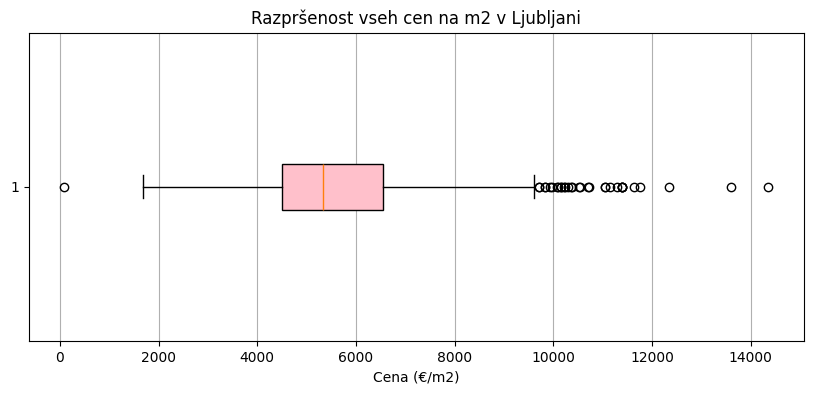

In [73]:
cene_m2 = cene_na_m2

if cene_m2:
    mediana = statistics.median(cene_m2)
    print(f"Mediana cene na m2 (vsi podatki): {mediana:,.2f} €/m²")

plt.figure(figsize=(10, 4))
plt.boxplot(cene_m2, vert=False, patch_artist=True, boxprops=dict(facecolor='pink'))
plt.title("Razpršenost vseh cen na m2 v Ljubljani")
plt.xlabel("Cena (€/m2)")
plt.grid(axis='x')
plt.show()

Zgornji graf z brki prikazuje realno razpršenost cen na trgu, kjer sredinska črta predstavlja mediano, obarvana škatla pa osrednjih 50 % vseh nepremičnin, katerih se cena razteza med približno 4.500 in 6.500 €/m².
Povprečna cena, 5.662,69 €/m², je opazno višja od mediane, 5.324,46 €/m². Ta razlika pove, da na trgu obstajajo drage nepremičnine, ki vplivajo na povprečje. Mediana torej pove, da točno polovica vseh oglaševanih nepremičnin stane manj kot 5.324,46 €/m², druga polovica pa več.

##### Raztreseni graf: 
Ta prikazuje korelacijo med velikostjo nepremičnine in njeno ceno. 
S porastom velikosti v kvadratnih metrih se v povprečju zvišuje tudi cena nepremičnine, kar se vidi na grafu, ki se pomika navzgor proti desni. Velika večina podatkov je zgoščenih v spodnjem levem delu grafa. To pomeni, da je na trgu največ manjših nepremičnin, katerih cene se gibljejo pod 1 milijonom evrov.

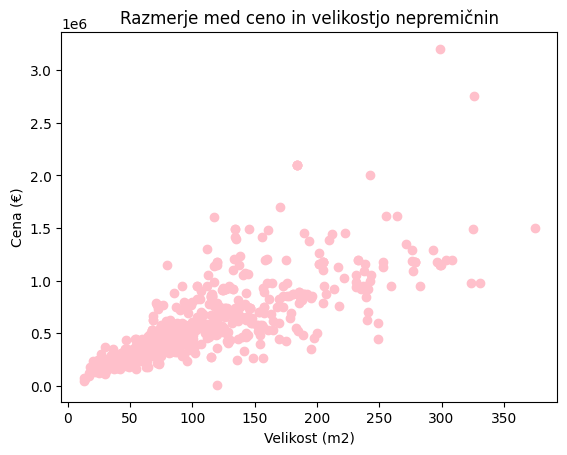

In [75]:
plt.scatter(velikosti, cene, color='pink')
plt.title("Razmerje med ceno in velikostjo nepremičnin")
plt.xlabel("Velikost (m2)")
plt.ylabel("Cena (€)")
plt.show()

In [94]:
korelacija = np.corrcoef(velikosti, cene)[0, 1]
print(f"Korelacijski koeficient: {korelacija:.2f}")

Korelacijski koeficient: 0.76


Korelacijski koeficient med velikostjo nepremičnine in njeno ceno znaša 0.76, kar pomeni, da sta dejavnika zelo povezana, večje nepremičnine so dražje. Vrednost ni enaka 1, ker cena ni odvisna samo od velikosti, temveč tudi od lokacije, leta izgradnje, tipa stanovanja in stanja nepremičnine, kar pojasnjuje razpršenost točk okoli glavnega trenda na razpršenem grafu.

In [84]:
# plt.figure()
# hb = plt.hexbin(velikosti, cene, gridsize=20, cmap='Reds', mincnt=1)
# plt.colorbar(hb, label='Število oglasov')

# plt.gca().set(
#     title="Gostota nepremičnin glede na velikost in ceno",
#     xlabel="Velikost (m2)",
#     ylabel="Cena (€)"
# )
# plt.show()

### Tip nepremičnine
Analizirati sem želela tudi vpliv tipa nepremičnin, saj v veliko primerih je bolj pomembna razporeditev stanovanja oziroma število sob, ki ga ta ima. Ljudem je bolj pomembno, da imajo določeno število sob, ki bo zadovoljilo vse družinske člane in ne le skupna velikost.

##### Stolpični diagram

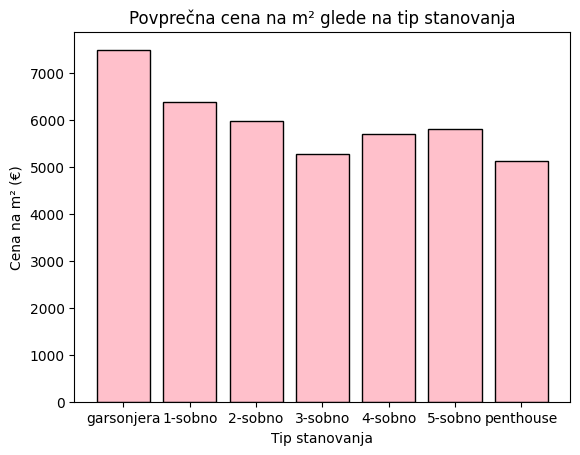

In [ ]:
tip_vrstni_red = ["garsonjera", "1-sobno", "2-sobno", "3-sobno", "4-sobno", "5-sobno", "penthouse"]

povprecja_po_tipu = {}
for c, v, t in zip(cene, velikosti, tipi):
    if t and v > 0:
        povprecja_po_tipu.setdefault(t, []).append(c / v)

tipi_prikaz = [t for t in tip_vrstni_red if t in povprecja_po_tipu]
povprecne_vrednosti = [sum(povprecja_po_tipu[t]) / len(povprecja_po_tipu[t]) for t in tipi_prikaz]

plt.figure()
plt.bar(tipi_prikaz, povprecne_vrednosti, color='pink', edgecolor='black')
plt.title("Povprečna cena na m² glede na tip stanovanja")
plt.xlabel("Tip stanovanja")
plt.ylabel("Cena na m² (€)")
plt.show()


Stolpični diagram prikazuje, da garsonjere in enosobna stanovanja izstopajo z najvišjo povprečno ceno na m². To menim, da je posledica velikega povpraševanja po manjših nepremičninah, ker si večjih preprosto ne morejo vsi privoščiti. Presenetilo me je to, da je povprečna cena 3-sobnih stanovanj nižja od 4 in 5-sobnih. Najnižja povprečna cena na m² je pri tako imenovanih penthousih, saj je povpraševanje po njih najmanjše zaradi največje skupne cene.

### Leto izgradnje
Zelo pomemben dejavnik pri tako velikem nakupu je tudi leto izgradnje oziroma starost nepremičnine. Želim preveriti ceno nepremičnin glede na leto izgradnje, ker je v večini oglasov poudarjeno, če ta spada v novogradnjo.

##### Tortni diagram
Tu je razvidno, da največji delež predstavljajo nepremičnine, zgrajene do leta 1960, ta delež me je najbolj presenetil, ker je zelo visok za hitro razvijajoče se mesto kot je Ljubljana. Stanovanja zgrajena po letu 2021 predtavljajo 27% vseh nepremičnin, ta meja je zelo pomembna, saj ta spadajo pod novogradnjo. 

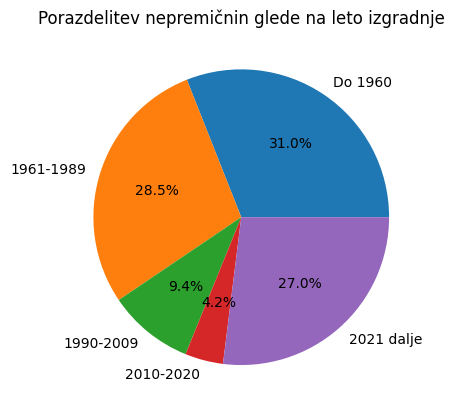

In [103]:
meje = [-np.inf, 1960, 1989, 2009, 2020, np.inf]
oznake = ["Do 1960", "1961-1989", "1990-2009", "2010-2020", "2021 dalje"]
stevilke, _ = np.histogram(leta, bins=meje)

plt.pie(stevilke, labels=oznake, autopct='%1.1f%%')
plt.title("Porazdelitev nepremičnin glede na leto izgradnje")
plt.show()

##### Stolpični diagram
Glede na ta enaka obdobja iz tortnega diagrama sem izračunala povprečno ceno na m².

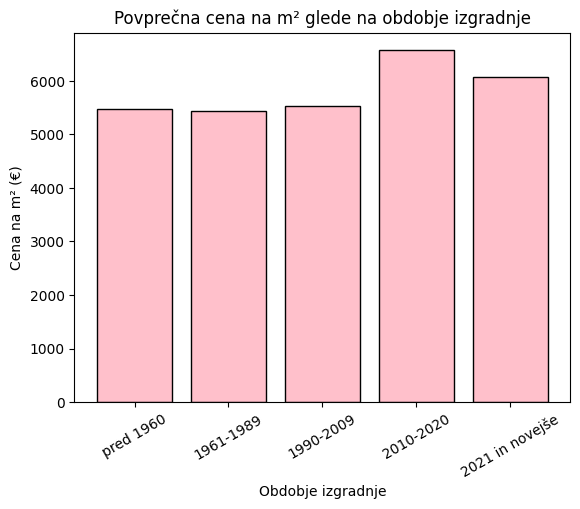

In [106]:
def doloci_obdobje(leto):
    if leto < 1960: return "pred 1960"
    elif leto < 1990: return "1961-1989"
    elif leto < 2010: return "1990-2009"
    elif leto < 2021: return "2010-2020"
    else: return "2021 in novejše"

obdobje_vrstni_red = ["pred 1960", "1961-1989", "1990-2009", "2010-2020", "2021 in novejše"]
cene_po_obdobjih = {}

for cena, velikost, leto in zip(cene, velikosti, leta):
    if velikost > 0:  
        obdobje = doloci_obdobje(leto)

        if obdobje not in cene_po_obdobjih:
            cene_po_obdobjih[obdobje] = []

        cena_na_m2 = cena / velikost
        cene_po_obdobjih[obdobje].append(cena_na_m2)

povprecja = []
for obdobje in obdobje_vrstni_red:
    seznam_cen = cene_po_obdobjih.get(obdobje, [])
    if len(seznam_cen) > 0:
        povprecje = sum(seznam_cen) / len(seznam_cen)
        povprecja.append(povprecje)
    else:
        povprecja.append(0)

plt.figure()
plt.bar(obdobje_vrstni_red, povprecja, color='pink', edgecolor='black')
plt.title("Povprečna cena na m² glede na obdobje izgradnje")
plt.xlabel("Obdobje izgradnje")
plt.ylabel("Cena na m² (€)")
plt.xticks(rotation=30)
plt.show()

Cena na kvadratni meter je presenetljivo stabilna za vse gradnje pred letom 2010 in šele pri stanovanjih, zgrajenih po letu 2010, opazno naraste na približno. To nakazuje, da starost stavbe sama po sebi ni ključni dejavnik cene, dokler ne gre za sodobno gradnjo, kjer je vzrok za višjo ceno verjetno sodobnejši standardi gradnje in dejstvo, da so te nepremičnine pogosto na novih urejenih in razvitih lokacijah. Presenetljivo je le, da je povprečna cena na m² nepremičnin, zgrajenih med letom 2010-2020 višja od najnovejših, zgrajenih v zadnjih petih letih. 

## Analiza
Analiza 671 oglasov za prodajo stanovanj v Ljubljani potrjuje, da je nepremičninski trg v resnično drag. Cena je povezana z vsemi tremi analiziranimi dejavniki, velikostjo nepremičnine, tipom in letom izgradnje, pri čemer manjše enote (garsonjere, 1-sobna stanovanja) in tiste, zgrajene po letu 2010 dosegajo bistveno višjo ceno na kvadratni meter kot večji objekti ter tisti zgrajeni pred letom 2010. Presenetljivo starost objekta sama po sebi nima velikega vpliva na ceno vse do zadnjega desetletja, ko sodobna gradnja doseže občutno višje cene od starejših objektov. Rezultati kažejo, da je pri iskanju cenovno ugodnejše nepremičnine v Ljubljani smiselno iskati med večjimi, starejšimi stanovanji (3-sobnimi), medtem ko manjše enote nosijo najvišje na m² ne glede na leto izgradnje.

Omejitev analize je vezana na kakovost podatkov: v vzorcu je bila najdena vsaj ena očitna napaka pri vnosu leta izgradnje, prav tako pa manjka podatek o tipu stanovanja pri več kot 80 stanovanjih, kar ima lahko velik vpliv na rezultate analize. 